# Assignment 1: GridWorld MDP from Scratch
**Prerequisites:** Read `lecture_notes.md` §1–5 before starting.

**Learning objectives:**
- Implement a stochastic GridWorld as a formal MDP
- Perform policy evaluation by solving Bellman equations iteratively
- Visualize value functions as heatmaps
- Observe how discount factor γ changes agent behavior

## Part 1: Theory Recap

The Bellman expectation equation for $V^\pi$:

$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)\bigl[R(s,a,s') + \gamma V^\pi(s')\bigr]$$

Policy evaluation iterates this update until $\max_s |V_{k+1}(s) - V_k(s)| < \theta$.

The state-value and action-value functions are related by:

$$V^\pi(s) = \sum_a \pi(a|s)\, Q^\pi(s,a)$$

A **stochastic** GridWorld adds a slip probability: with prob `slip/2` each, the agent moves
in one of the two perpendicular directions instead of the intended one.

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Dict, List, Tuple, Optional

## Part 2: Implementation

Implement the `GridWorld` class below. Each method has a docstring explaining what it should do.
All unimplemented methods raise `NotImplementedError` — replace that with your implementation.

**Hints:**
- For `get_transitions`: terminal states should absorb (return immediately, no further transitions).
- For `policy_evaluation`: terminal states always have value 0; do not update them.
- For `visualize_values`: use `plt.imshow`, annotate each cell with its value, overlay arrows.

In [224]:
class GridWorld:
    """
    Configurable stochastic GridWorld MDP.

    Grid symbols:
        ' ' = empty cell
        'W' = wall (impassable; not a state)
        'G' = goal  (reward +1, terminal)
        'H' = hole  (reward -1, terminal)
        'S' = start (reward  0, non-terminal)

    Actions: 0=up, 1=right, 2=down, 3=left.

    Stochastic dynamics (slip > 0):
        With prob (1 - slip): take intended action.
        With prob slip/2:     move perpendicular left  (action - 1) % 4.
        With prob slip/2:     move perpendicular right (action + 1) % 4.

    If an action would move the agent into a wall or off the grid, the agent stays in place.
    """
    ACTIONS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    ACTION_NAMES = {0: '↑', 1: '→', 2: '↓', 3: '←'}

    def __init__(self, grid: List[List[str]], gamma: float = 0.99, slip: float = 0.0):
        """
        Parameters
        ----------
        grid  : 2-D list of strings (symbols defined above).
        gamma : discount factor ∈ [0, 1).
        slip  : probability of a perpendicular move ∈ [0, 1).
        """
        self.grid = np.array(grid)
        self.gamma = gamma
        self.slip = slip
        self.states = [(x,y) for x in range(len(grid)) for y in range(len(grid[0]))]

        self.n_cols = len(grid[0])
        self.n_rows = len(grid)

        self.terminal: set = set()
        self.walls: set = set()

        for r in range(self.n_rows):
            for c in range(self.n_cols):
                cell = grid[r][c]
                if cell == 'W':
                    self.walls.add((r, c))
                else:
                    if cell in ('G', 'H'):
                        self.terminal.add((r, c))

    def _reward(self, state: Tuple) -> float:
        """
        Return the immediate reward for *being in* `state`.

        +1.0 for goal 'G', -1.0 for hole 'H', 0.0 otherwise.
        """
        if self.grid[state] == 'G':
            return 1.0

        if self.grid[state] == 'H':
            return -1.0
            
        else:
            return 0.0

    def _next_state(self, state: Tuple, action: int) -> Tuple:
        """
        Return the deterministic next state when taking `action` from `state`.

        If the resulting position is out-of-bounds or a wall, return `state` unchanged
        (the agent bounces back).
        """
        new_state = list(state)
        
        new_state[0] += GridWorld.ACTIONS[action][0]
        new_state[1] += GridWorld.ACTIONS[action][1]

        if new_state[0] < 0 or new_state[0] >= len(self.grid):
            new_state = state

        if new_state[1] < 0 or new_state[1] >= len(self.grid[0]):
            new_state = state

        return tuple(new_state)

    def get_transitions(self, state: Tuple, action: int) -> List[Tuple[float, Tuple, float, bool]]:
        """
        Return the full transition distribution for (state, action).

        Returns a list of tuples: (probability, next_state, reward, done).

        Special cases:
        - If `state` is terminal, return [(1.0, state, 0.0, True)] — the episode is over,
          no reward is collected and the agent stays in the absorbing terminal state.
        - If slip == 0, the list has exactly one entry with probability 1.0.
        - If slip > 0, merge probabilities for identical next_states (so the list never has
          duplicate next_states).

        Steps to implement:
        1. Return early if state is terminal.
        2. Compute perpendicular actions: left = (action - 1) % 4, right = (action + 1) % 4.
        3. Build a raw list: [(1 - slip, intended), (slip/2, perp_left), (slip/2, perp_right)].
        4. For each (prob, act), compute next_state = self._next_state(state, act).
        5. Merge: accumulate probabilities for identical next_states into a dict, then convert
           back to a list of (prob, next_state, reward, done) tuples.
        6. reward = self._reward(next_state); done = next_state in self.terminal.
        """

        if self.grid[state[0]][state[1]] == 'G' or self.grid[state[0]][state[1]] == 'H':
            return [(1.0, state, 0.0, True)]

        p = 1.0
        next_states = {}
        
        if self.slip == 0:
            next_state = self._next_state(state, action)
            next_states[next_state] = next_states.get(next_state, 0.0) + p
            
        else:
            perp_left = (action - 1) % 4
            perp_right = (action + 1) % 4

            prob_ac = [(1-self.slip, action), (self.slip/2, perp_left), (self.slip/2, perp_right)]
            
            for pr,a in prob_ac:
                next_state = self._next_state(state, a)

                next_states[next_state] = next_states.get(next_state, 0.0) + pr

        res = []

        for n in next_states:
            reward = self._reward(n)
            done = self.grid[n] in self.terminal
            res.append((next_states[n], n, reward, done))
            
        return res
        

    def policy_evaluation(self, policy: Dict[Tuple, int], theta: float = 1e-8) -> Dict[Tuple, float]:
        """
        Iterative policy evaluation. Repeatedly apply:

            V(s) ← Σ_{s'} P(s'|s,π(s)) [R(s,π(s),s') + γ V(s')]

        until max_s |V_new(s) - V_old(s)| < theta.

        Returns V: dict mapping each state → float value.

        Common mistakes to avoid:
        - Do NOT update terminal states; their value is always 0.
        - Use the value from the *start* of the sweep (synchronous update), not in-place
          updates within a sweep — or equivalently, use in-place but track delta correctly.
          (Either synchronous or in-place/asynchronous converges; synchronous is cleaner.)

        Steps to implement:
        1. Initialize V = {s: 0.0 for s in self.states}.
        2. Outer loop: repeat until delta < theta.
        3. Inner loop: for each non-terminal state s, compute the Bellman update using
           self.get_transitions(s, policy[s]).
        4. Track delta = max over all states of |V_new(s) - V_old(s)|.
        5. Return V.
        """

        V = {s: 0.0 for s in self.states}

        iter_num = 0
        
        while True:
            
            delta = 0.0
            for s in self.states:
                new_V = 0.0
                
                if s not in self.terminal:
                    ns = self.get_transitions(s, policy[s])

                    for n in ns:
                        # print(n[0], n[2], n[1])
                        new_V += n[0] * (n[2] + self.gamma * V[n[1]])
                    delta = max(delta, abs(new_V - V[s]))

                V[s] = new_V
                
            iter_num += 1
            
            if delta < theta:
                print("Theta breaked ", delta, iter_num)
                break
                
        return V

    def visualize_values(self,
                         V: Dict[Tuple, float],
                         policy: Optional[Dict[Tuple, int]] = None,
                         title: str = "Value Function"):
        """
        Visualize the value function as a heatmap. Optionally overlay policy arrows.

        Steps to implement:
        1. Create a 2-D numpy array `grid_vals` of shape (n_rows, n_cols) filled with np.nan.
        2. Fill in grid_vals[r][c] = V[(r,c)] for each non-wall, non-terminal state.
           Set terminal 'G' cells to +1.0 and 'H' cells to -1.0 for visual clarity.
        3. Use plt.imshow(grid_vals, cmap='RdYlGn', vmin=-1, vmax=1) for a red-yellow-green
           color scale (red = bad, green = good).
        4. Annotate each non-wall cell with its value (2 decimal places).
        5. If policy is provided, overlay ACTION_NAMES arrows on non-terminal states.
        6. Mark wall cells as black (set their alpha or fill with a black patch).
        7. Add title, colorbar, and plt.tight_layout(); call plt.show().
        """

        grid_vals = np.ones((len(self.grid), len(self.grid[0]))) * np.nan

        for s in V:
            # print(s, self.grid[s], V[s])
            if s not in self.terminal and self.grid[s] != 'W':
                grid_vals[s] = V[s]

            if self.grid[s] == 'G':
                grid_vals[s] = +1.0

            if self.grid[s] == 'H':
                grid_vals[s] = -1.0

        # print(grid_vals)

        fig, ax = plt.subplots(figsize=(self.n_cols * 1.2, self.n_rows * 1.2))
        im = ax.imshow(grid_vals, cmap='RdYlGn', vmin=-1, vmax=1, aspect='equal')

        # Mark walls black
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if (r, c) in self.walls:
                    ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color='black'))

        # Annotate cells
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                state = (r, c)
                if state in self.walls:
                    continue
                val = grid_vals[r,c]
                if not np.isnan(val):
                    ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                            fontsize=8, color='black')

        # Overlay policy arrows
        if policy is not None:
            for s in self.states:
                if s in self.terminal:
                    continue
                r, c = s
                if s in policy:
                    ax.text(c, r - 0.3, self.ACTION_NAMES[policy[s]],
                            ha='center', va='center', fontsize=12, color='navy')

        ax.set_title(title)
        ax.set_xticks(range(self.n_cols))
        ax.set_yticks(range(self.n_rows))
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()

        

## Part 3: Training & Verification

Run policy evaluation on a random policy over the standard 4×4 GridWorld.
The verification checks that terminal states have V ≈ 0 (required by convention).

Theta breaked  0.0 2


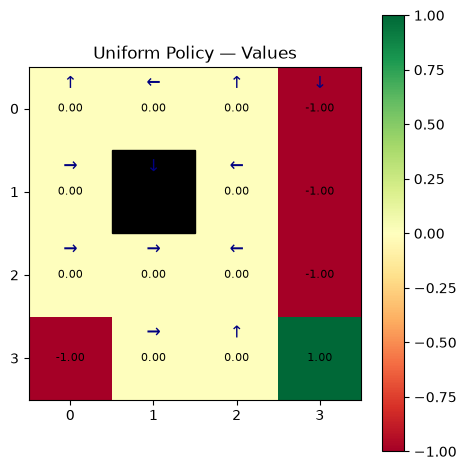

✓ Terminal state values correct


In [248]:
# Standard 4x4 grid (similar to FrozenLake-v1)
GRID = [
    ['S', ' ', ' ', ' '],
    [' ', 'W', ' ', 'H'],
    [' ', ' ', ' ', 'H'],
    ['H', ' ', ' ', 'G'],
]

env = GridWorld(GRID, gamma=0.99, slip=0.0)
uniform_policy = {s: np.random.randint(4) for s in env.states}

V = env.policy_evaluation(uniform_policy, theta=1e-9)
env.visualize_values(V, uniform_policy, "Uniform Policy — Values")

# Verification: terminal states should have value 0.0
for s in env.terminal:
    assert abs(V.get(s, 0.0)) < 1e-3, f"Terminal state {s} should have V≈0, got {V.get(s)}"
print("✓ Terminal state values correct")

## Part 4: Ablations

**Ablation 1:** Change `gamma` from 0.99 → 0.1. Rerun policy_evaluation.
What happens to the values of states far from the goal?

Theta breaked  0.0 4


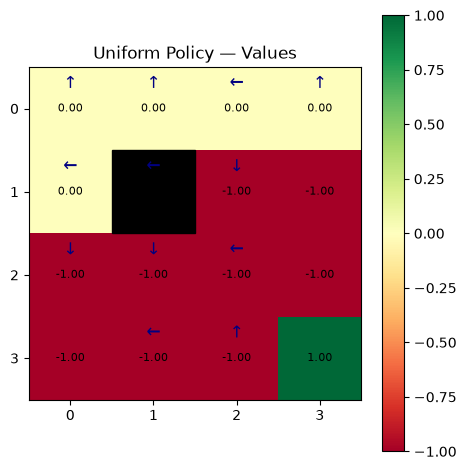

In [222]:
# Ablation 1: myopic agent
# TODO: create GridWorld with gamma=0.1, evaluate same policy, visualize, compare
env = GridWorld(GRID, gamma=1, slip=0)
uniform_policy = {s: np.random.randint(4) for s in env.states}

V = env.policy_evaluation(uniform_policy)
env.visualize_values(V, uniform_policy, "Uniform Policy — Values")

**Observation (fill in):** With gamma=0.1, states far from the goal have values close to ___
because ___.

Theta breaked  9.954155754110516e-07 303


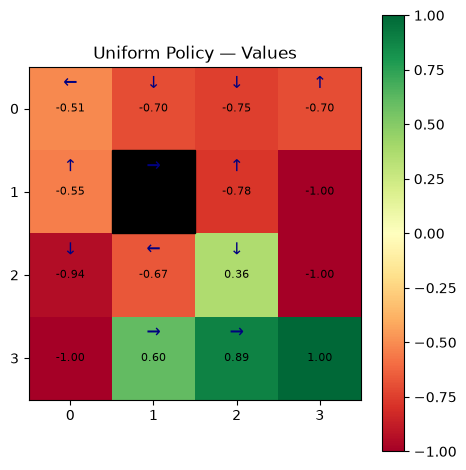

In [223]:
# Ablation 2: slip=0.3 (very stochastic environment)
# TODO: evaluate same policy with slip=0.3; note how uncertainty degrades values near holes
env = GridWorld(GRID, gamma=0.99, slip=0.3)
uniform_policy = {s: np.random.randint(4) for s in env.states}

V = env.policy_evaluation(uniform_policy)
env.visualize_values(V, uniform_policy, "Uniform Policy — Values")

**Observation (fill in):** With slip=0.3, the value of states adjacent to holes ___
compared to slip=0.0 because ___.

## Part 5: Reflection

Answer the questions below in the markdown cell provided.

1. Why is the Markov property essential for policy evaluation to work?
2. RLHF reward models score full responses (not per-token). How does this relate
   to the credit assignment problem you just saw in GridWorld?
3. If gamma=1 and the environment has no terminal state, what goes wrong in policy_evaluation?

In [ ]:
# Your answers here (markdown cell below)

**Answers:**
1.
2.
3.